## What is the benefit of screening for ovarian cancer ?  
Автор описує ситуацію з реального кейсу 2015 року про 
велике 11-річне дослідження скринінгу раку яєчників
( вибірка подан 200000 жінок ).
Дослідники зробили все " за підручником"
зазделегідь зафіксували протокол, метрики, гіпотезу.
Результат: відсутність статистично значущої різниці. 
Дослідники про це чесно написали. 
Парадокс: наступного газета виходить із заголовком:
"Величезний успіх нового методу"
Це підводить нас до думки: щоб виправити кризу в статистиці,
діяти має не хтось один, а вся система. 



**Автор кажи щоб виправити це, три групи повинні змінити поведінку:**  

Producers of statistics: scientists, statisticians - вони мають
робити статистику кращою ( прозорість, кращий дизайн експеременту, 
p-hacking )
Communicators: наукові журнали, журналісти, редактори - вони 
мають передавати статистику чесніше ( без клікбейту і перебільшення
результатів, не як у випадку з дослідження описаним вище )
Audiences: ми-публіка, бізнес, політика - вони мають перевіряти статистику 
критичніше ( не вірити гучним заголовкам, запитувати про незрозумілі речі )


**Конкретні рекомендації, як кожна група може покращити роботу  
зі статистикою:**    
**Improving What Is Produced**  
Найкращий захист від підгонки результатів під бажану відповідь
( p-hacking ) - це Pre-registration, тобто фіксація: гіпотези,
метрики, методу ще до того як дані зібрані.
Автор також застерігає від фанатизму, у прикладі зі скринінгом раку:
аналітики зафіксували правило: "рахуємо всіх пацієнтів" і тест показав
незначущий результат. Якби вони виключили тих, хто вже був хворий до початку
тесту ( що логічно ), результат став би значущим ( 20% зниження смертності,
P = 0.02 ) 
Висноков: Потрібно розділяти Confirmatory data analysis ( суворе тестування
зафіксованої гіпотези ); Exploratory data analysis ( дослідження даних у 
пошуках нових інсайтів ). Обидва важливі, але потрібно їх розділяти.

**Improving Communication**  
Медіа вимагають гучних головків, стейкхолдери чорно-білих висновків. 
Але справжня статистика - це ймовірність, компроміси. 
Хороший комунікатор має вміти "продавати" невизначеність. 
Варто пам'ятати про правило "Suspicious nose" - якщо 
бачимо гіганський ефект на малій вибірці - це 99% статичний викид.

**Publication Bias, P-curve**  
Якщо публікувати лише "успішні" тести ( P < 0.05 ) створюється ілюзія,
що продукт чи ліки працюють ідеально - це Publication Bias.
Щоб вивести на чисту воду використовується аналіз P-кривої.
Пояснення: якщо ефекту насправді немає ( H0 вірні ), то p-values 
від багатьох тестів будуть розподілені рівномірно від 0 до 1.
Якщо ефект є, p-values будуть скупчуватися біля нуля.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(13)
n_tests = 10000
sample_size = 30

# Сценарій 1: Ефекту немає А/A тест
# Групи ідентичні, різниця = 0
p_values_null = []
for _ in range(n_tests):
    a = np.random.normal(0, 1, sample_size)
    b = np.random.normal(0, 1, sample_size)
    p_values_null.append(stats.ttest_ind(a, b)[1])


# Сценарій 2: Є ефект А/B тест
# Група В справді краща ( на 0.5 стандартного відхилення)
p_values_real = []
for _ in range(n_tests):
    a = np.random.normal(0, 1, sample_size)
    b = np.random.normal(0.5, 1, sample_size)
    p_values_real.append(stats.ttest_ind(a, b)[1])



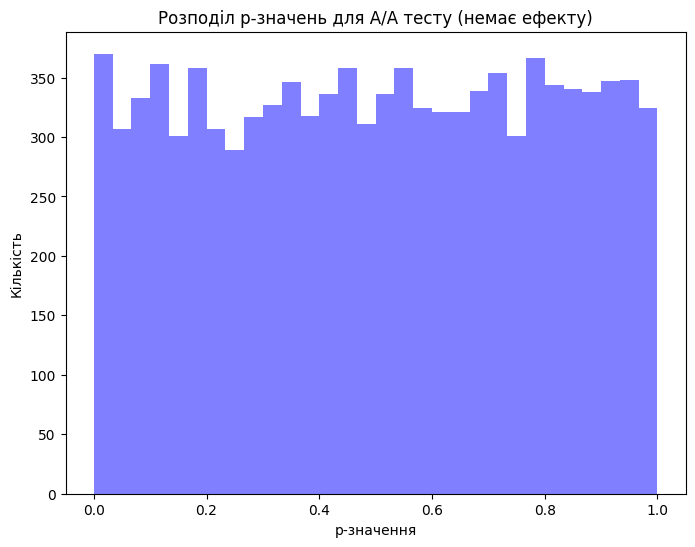

In [16]:
f, ax = plt.subplots(figsize=(8, 6))
ax.hist(p_values_null, bins=30, alpha=0.5, label='Null (A/A)', color='blue')
ax.set_title('Розподіл p-значень для A/A тесту (немає ефекту)')
ax.set_xlabel('p-значення')
ax.set_ylabel('Кількість')
plt.show()

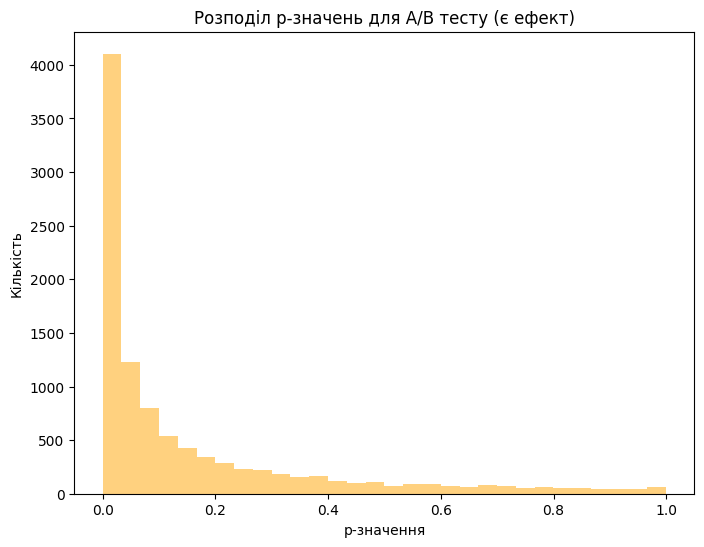

In [17]:
f, ax2 = plt.subplots(figsize=(8, 6))
ax2.hist(p_values_real, bins=30, alpha=0.5, label='Real (A/B)', color='orange')
ax2.set_title('Розподіл p-значень для A/B тесту (є ефект)')
ax2.set_xlabel('p-значення')
ax2.set_ylabel('Кількість')
plt.show()

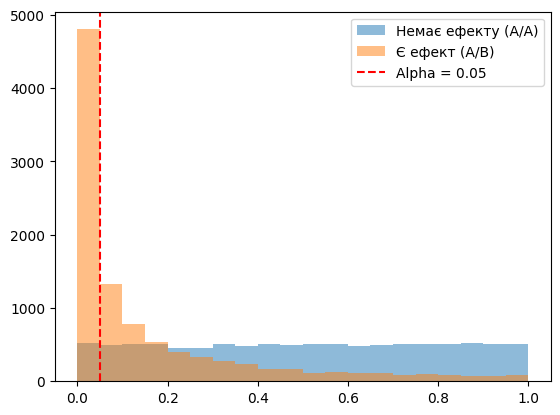

In [19]:
plt.hist(p_values_null, bins=20, alpha=0.5, label='Немає ефекту (A/A)')
plt.hist(p_values_real, bins=20, alpha=0.5, label='Є ефект (A/B)')
plt.axvline(x=0.05, color='red', linestyle='--', label='Alpha = 0.05')
plt.legend()
plt.show()